<a href="https://colab.research.google.com/github/cohench123/cohen_INFO4670_Spring2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [2]:
#Please write the code here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("car_purchase_data.csv")

# Preview data
print(data.head())
print(data.info())

    User ID  Gender  Age  Salary  Purchased
0  15624510    Male   19   19000          0
1  15810944    Male   35   20000          0
2  15668575  Female   26   43000          0
3  15603246  Female   27   57000          0
4  15804002    Male   19   76000          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   User ID    400 non-null    int64 
 1   Gender     400 non-null    object
 2   Age        400 non-null    int64 
 3   Salary     400 non-null    int64 
 4   Purchased  400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


### Step 2: Split features and target

In [3]:
#Please write the code here
x = data[['Age', 'Salary']]
y = data['Purchased']

### Step 3: Train/Test Split

In [4]:
#Please write the code here
# The dataset is being split into training and testing, 75% used for training 25% for testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42
)

### Step 4: Feature Scaling

In [5]:
#Please write the code here
# Scaler using standard scaler
scaler = StandardScaler()

# Fitting the scaler to our training data and then transforming it
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### Step 5: Train Logistic Regression Model

In [6]:
#Please write the code here
# Creating the model for logistic regression, and training the model with out training data
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

### Step 6: Predict and Evaluate

In [7]:
#Please write the code here
# Creating a prediction of outcomes of our dataset
y_prediction = model.predict(x_test)

# Calculating the accuracy of our model
accuracy = accuracy_score(y_test, y_prediction)
print("Accuracy:", accuracy)

# Creating a display of the confusion matrix in order to evaluate the performance of our prediction
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_prediction), "\n")

# Displaying precision, F1 score, and recall
print("Classification Report:")
print(classification_report(y_test, y_prediction))

Accuracy: 0.86
Confusion Matrix:
[[61  2]
 [12 25]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90        63
           1       0.93      0.68      0.78        37

    accuracy                           0.86       100
   macro avg       0.88      0.82      0.84       100
weighted avg       0.87      0.86      0.85       100



### Step 7: Visualization of Decision Regions

/tmp/ipykernel_7278/3446133318.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


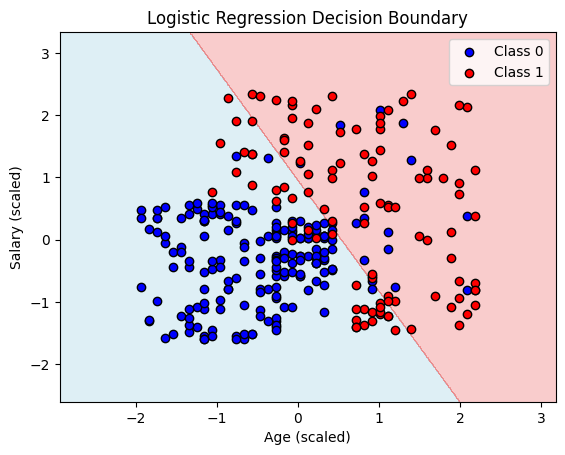

In [8]:
#Please write the code here
# Importing color map
from matplotlib.colors import ListedColormap

# Training data being put in for visualization
x_set, y_set = x_train, y_train

# Creating a grid for plotting the decision boundary
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
    np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01)
)

cmap_background = ListedColormap(('lightblue', 'lightcoral'))
cmap_points = ListedColormap(('blue', 'red'))

# Plotting the decision boundary with our model predicitons
plt.contourf(
    x1, x2,
    model.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
    alpha=0.4,
    cmap=cmap_background
)

# Plotting the actual data points
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        x_set[y_set == j, 0],
        x_set[y_set == j, 1],
        c=cmap_points(i),
        label=f"Class {j}",
        edgecolor='black'
    )

# Adding labeling
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Age (scaled)")
plt.ylabel("Salary (scaled)")
plt.legend()

plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. Logistic Regression can still be used for classification because it predicts a probability between 0 and 1 with the sigmoid function. With this probability we can use a threshold to see if the probability is greater than or equal to the threshold to determine an outcome of yes or no.

2. Based on the model customers who are older nad thus have higher salaries are the ones more likly to buy a car. The ones less likely to buy a car would be the younger customers as they have lower income.

3. There is some overlap with the blue and red points on the decision boundary, this can lead to misclassification. Factors that can lead to lower accuracy include overlapping data, outliers, and a linear decision boundary which might not fit the data distribution.

4. In order to improve the model's performance I would include factors like marital status, credit score, gender, and education level. I think that handling or removing the outliers can also improve the data. Finally I would normalize and clean the data more carefully in order to produce better results.